In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

%store -r datasets

In [ ]:
df = datasets['lotacao_completo']
df = df.sort_values(by='cumprimento', axis=0, ascending=True, inplace=False, na_position='last', ignore_index=False)
df.head()

,servico,mes,regiao,passageiros_total,viagens_total,cumprimento,passageiros_por_viagem
3348,601,2024-01,Zona Norte / Subúrbio,44250,495,0.0,89.393939
7779,SP601,2024-03,Zona Oeste,3688,112,0.0,32.928571
7777,SP601,2023-12,Zona Oeste,2015,115,0.0,17.521739
3350,601,2024-03,Zona Norte / Subúrbio,65938,753,0.0,87.567065
7776,SP601,2023-11,Zona Oeste,2022,98,0.0,20.632653


<Figure size 640x480 with 0 Axes>

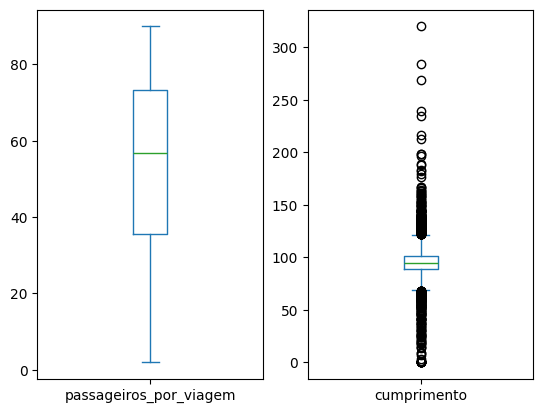

<Figure size 640x480 with 0 Axes>

In [3]:
df[['passageiros_por_viagem', 'cumprimento']].plot(kind='box', subplots=True)
plt.figure()

<Figure size 640x480 with 0 Axes>

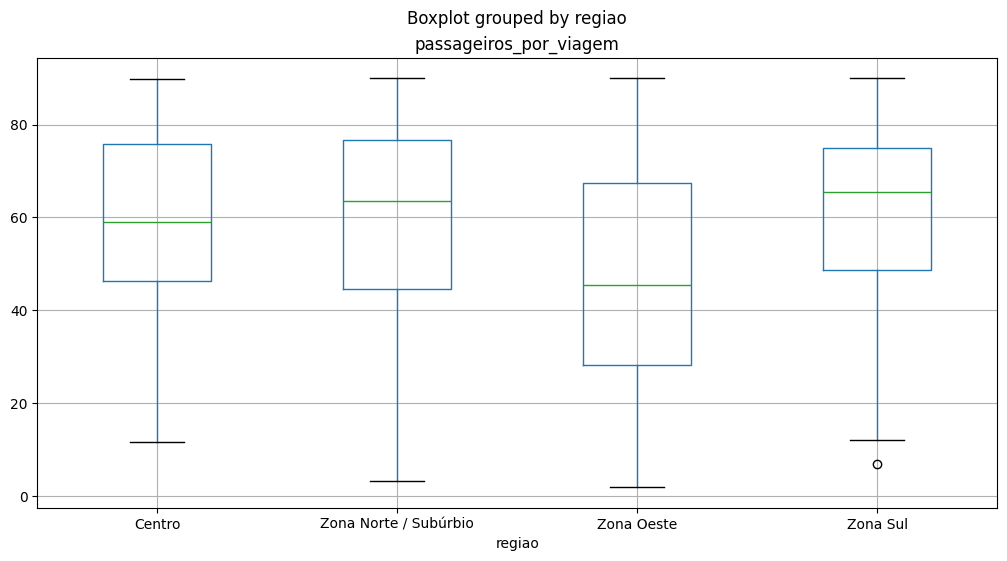

<Figure size 640x480 with 0 Axes>

In [4]:
df.boxplot(column='passageiros_por_viagem', by='regiao', figsize=(12, 6))
plt.figure()

<Figure size 640x480 with 0 Axes>

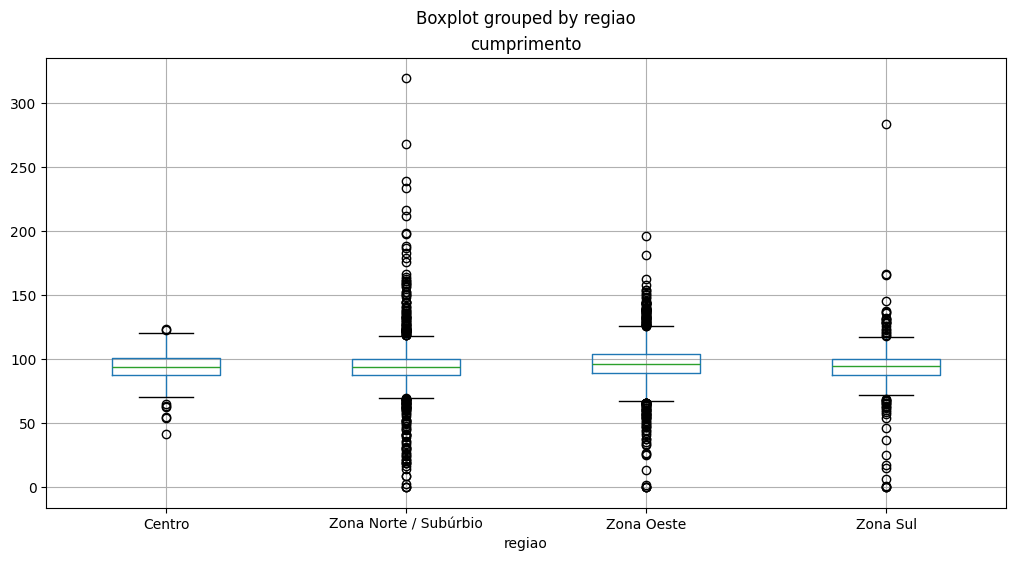

<Figure size 640x480 with 0 Axes>

In [5]:
df.boxplot(column='cumprimento', by='regiao', figsize=(12, 6))
plt.figure()

<Figure size 640x480 with 0 Axes>

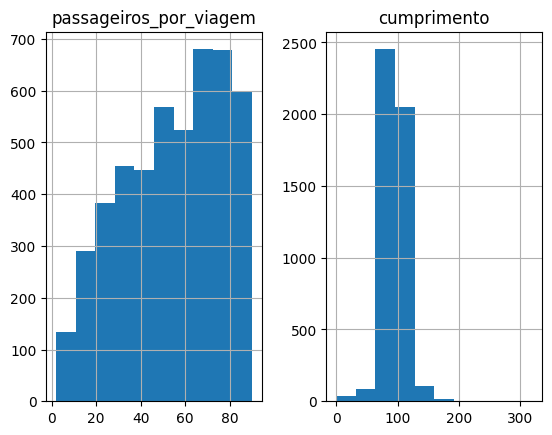

<Figure size 640x480 with 0 Axes>

In [6]:
df[['passageiros_por_viagem', 'cumprimento']].hist()
plt.figure()

<Figure size 640x480 with 0 Axes>

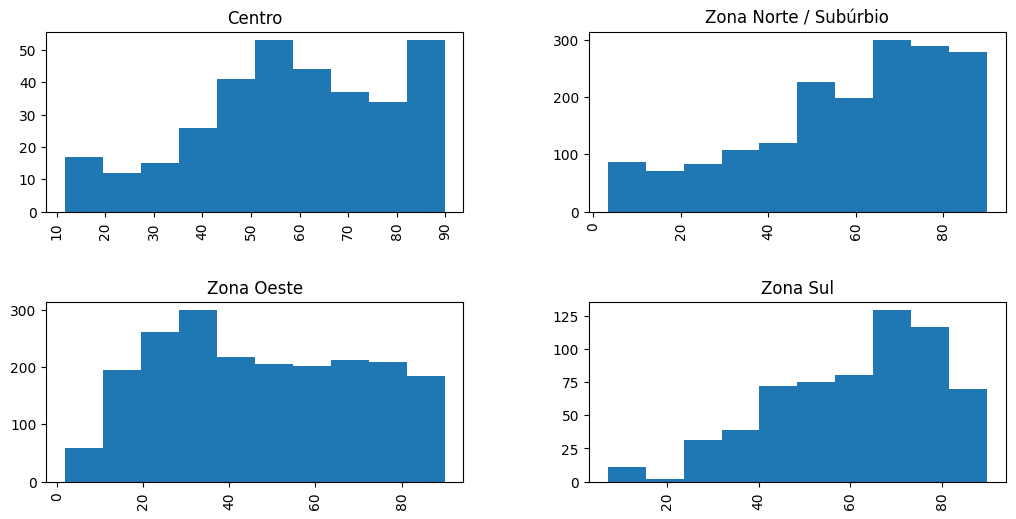

<Figure size 640x480 with 0 Axes>

In [7]:
df.hist(column='passageiros_por_viagem', by='regiao', figsize=(12, 6))
plt.figure()

<Figure size 640x480 with 0 Axes>

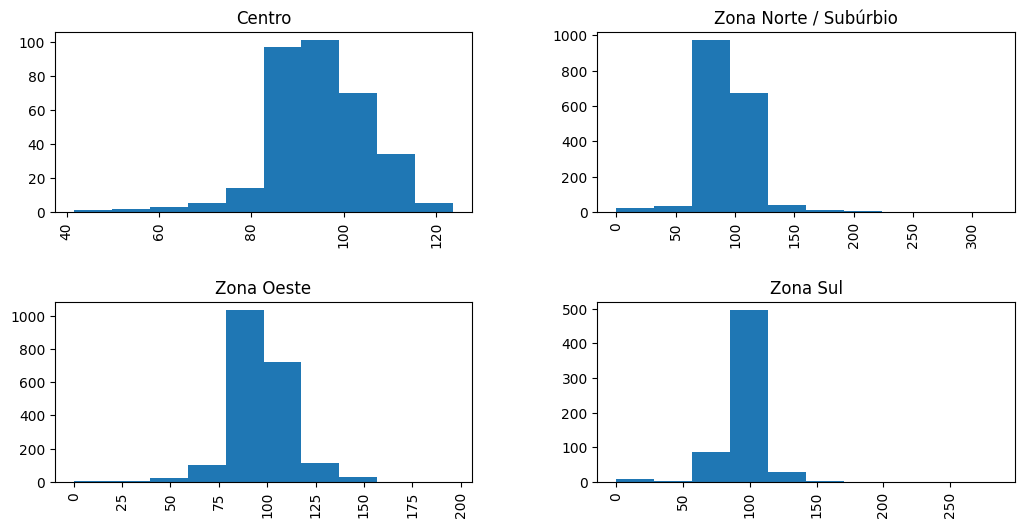

<Figure size 640x480 with 0 Axes>

In [8]:
df.hist(column='cumprimento', by='regiao', figsize=(12, 6))
plt.figure()

<Figure size 640x480 with 0 Axes>

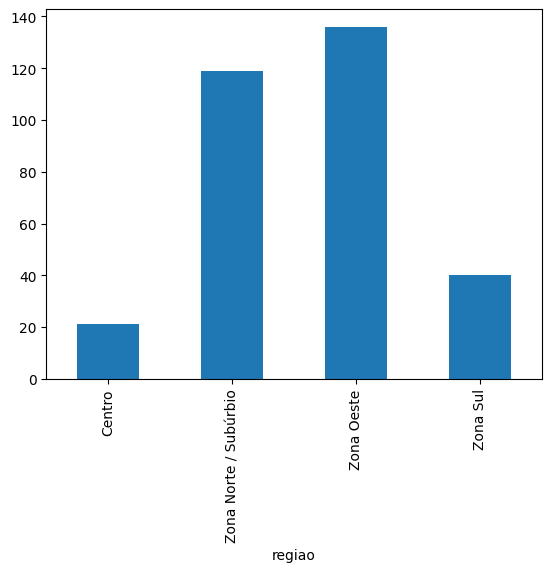

<Figure size 640x480 with 0 Axes>

In [9]:
df.groupby('regiao')['servico'].nunique().plot(kind='bar')
plt.figure()

In [10]:
df_agrupado = df.groupby(['servico', 'regiao'])[['passageiros_total', 'viagens_total']].sum()
df_agrupado.info()

<class 'pandas.DataFrame'>
MultiIndex: 316 entries, ('100', 'Zona Sul') to ('SVB901', 'Zona Norte / Subúrbio')
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   passageiros_total  316 non-null    int64
 1   viagens_total      316 non-null    int64
dtypes: int64(2)
memory usage: 8.5+ KB


,passageiros_total,viagens_total
passageiros_total,1.000000,0.963583
viagens_total,0.963583,1.000000


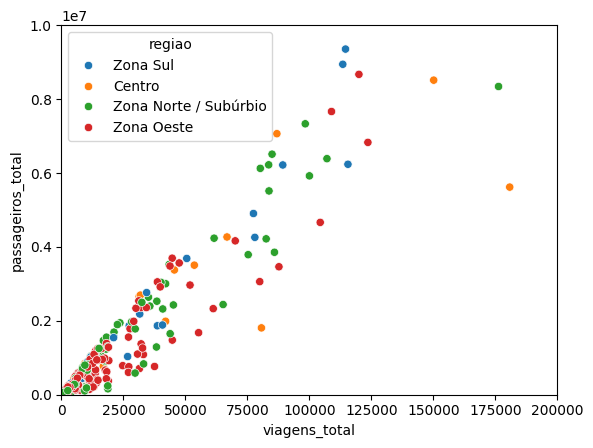

In [13]:
sns.scatterplot(x='viagens_total', y='passageiros_total', hue='regiao', data=df_agrupado)
plt.xlim(0,200000)
plt.ylim(0,10000000)
df_agrupado.corr()

In [40]:
df_ids = datasets['ids_por_bairro_rj']

gdf_bairros = gpd.read_file('../dados/Limite_de_Bairros.geojson').rename(columns={'nome': 'bairro'}).astype(str)
df_linha_bairro_com_cod = df_linha_bairro.merge(gdf_bairros[['bairro', 'codbairro']], on='bairro').astype(str)
df_linha_bairro_com_cod['codbairro'] = df_linha_bairro_com_cod['codbairro'].astype(int)
df_ids['codbairro'] = df_ids['codbairro'].astype(int)
df_linha_bairro_ids = df_linha_bairro_com_cod.merge(df_ids[['codbairro', 'ids']], on='codbairro')
df_linha_bairro_ids = df_linha_bairro_ids.groupby('bairro').agg({
    'codbairro': 'first',
    'ids': 'first',
    'regiao': 'first',
    'linha': 'nunique'  # Conta as linhas únicas
}).reset_index()
df_linha_bairro_ids.head(1000)


,bairro,codbairro,ids,regiao,linha
0,Abolição,70,0.613303,Zona Norte / Subúrbio,24
1,Acari,111,0.512086,Zona Norte / Subúrbio,34
2,Alto da Boa Vista,34,0.524369,Zona Norte / Subúrbio,5
3,Anchieta,107,0.554227,Zona Oeste,19
4,Andaraí,37,0.644252,Zona Norte / Subúrbio,15
...,...,...,...,...,...
152,Vila Valqueire,125,0.635159,Zona Oeste,23
153,Vila da Penha,74,0.640781,Zona Norte / Subúrbio,18
154,Vista Alegre,75,0.620438,Zona Norte / Subúrbio,12
155,Zumbi,92,0.660360,Zona Norte / Subúrbio,9


<Axes: xlabel='ids', ylabel='linha'>

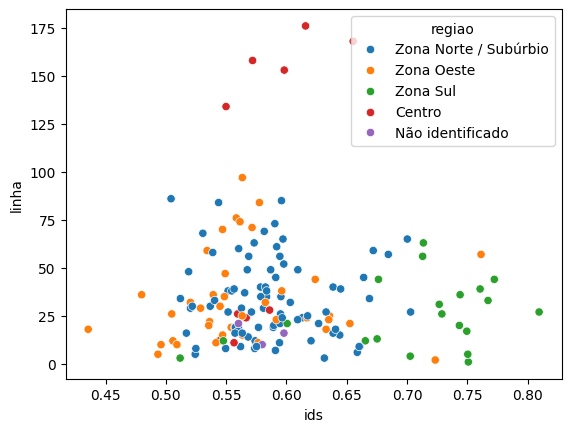

In [41]:
sns.scatterplot(x='ids', y='linha', hue='regiao', data=df_linha_bairro_ids)


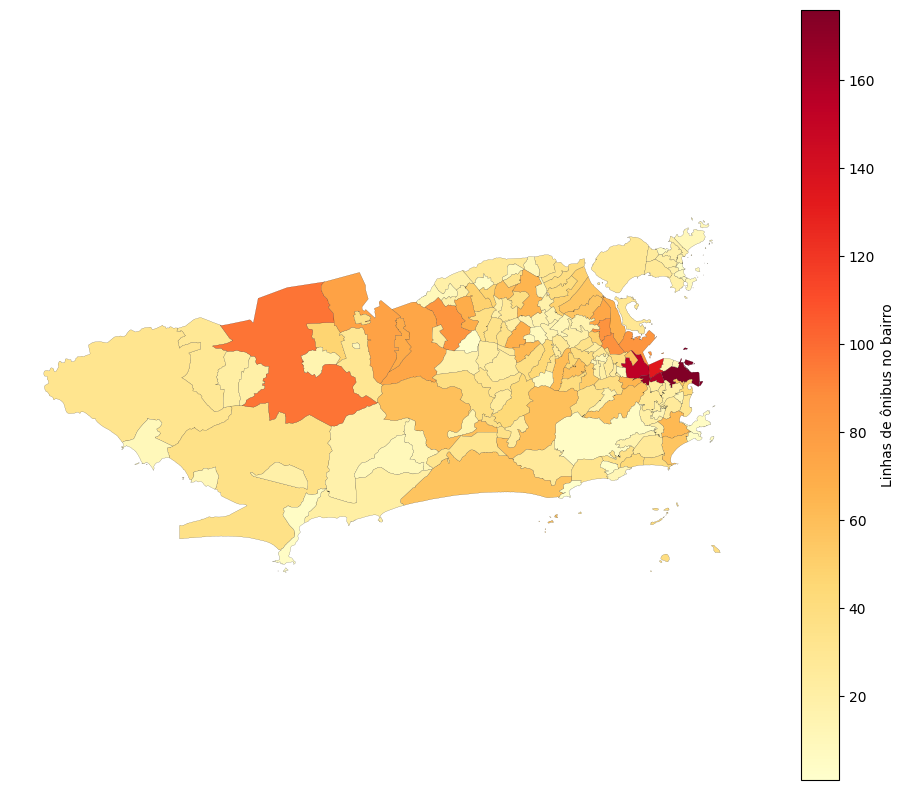

In [ ]:
contagem_linhas = datasets['matriz_linha_bairro'].groupby('bairro')['linha'].nunique().reset_index()
contagem_linhas = contagem_linhas.rename(columns={'linha': 'quantidade_linhas'})

gdf_bairros = gpd.read_file('../dados/Limite_de_Bairros.geojson')
mapa_linhas = gdf_bairros.merge(contagem_linhas, left_on='nome', right_on='bairro', how='left')

mapa_linhas['quantidade_linhas'] = mapa_linhas['quantidade_linhas']
mapa_linhas = gpd.GeoDataFrame(mapa_linhas, geometry='geometry')
mapa_linhas = mapa_linhas.to_crs(4326)

mapa_linhas.plot(column='quantidade_linhas', cmap='YlOrRd', linewidth=0.1, edgecolor='black', legend=True, legend_kwds={'label': "Linhas de ônibus no bairro", 'orientation': "vertical"}, figsize=(12, 10)).set_axis_off()

#Testando
mapa_interativo = mapa_linhas.explore(
    column='quantidade_linhas',
    cmap='YlOrRd',
    tooltip=['bairro', 'quantidade_linhas'], 
    legend_name='Total de Linhas',
    tiles='CartoDB positron'
)




In [ ]:
#Teste de mapa
mapa_interativo.save("meu_mapa_rj.html")